In [22]:
import argparse
import os
import glob
import pickle
import pandas as pd
import numpy as np
import pprint
from datetime import datetime
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pyspark
import pyspark.sql.functions as F
from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

In [2]:
# Build a .py script that takes a snapshot date, loads a model artefact and make an inference and save to datamart

In [23]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/30 07:47:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Configuration

In [3]:
snapshot_date_str = "2024-09-01"
modelname = "credit_model_2024_09_01.pkl"

In [4]:
# --- Configuration ---
config = {}
config["snapshot_date_str"] = snapshot_date_str
config["snapshot_date"] = datetime.strptime(config["snapshot_date_str"], "%Y-%m-%d")
config["model_bank_directory"] = "model_bank/"
config["predictions_directory"] = "datamart/gold/model_predictions/"
config["label_store_directory"] = "datamart/gold/label_store/"
config["drift_flag_path"] = "datamart/gold/model_drift_detected.flag"
config["drift_threshold"] = -0.05  # threshold set at 5% , more than that defined as drift
config["model_name"] = modelname
config["model_bank_directory"] = "model_bank/"
config["model_artefact_filepath"] = config["model_bank_directory"] + config["model_name"]

pprint.pprint(config)

{'drift_flag_path': 'datamart/gold/model_drift_detected.flag',
 'drift_threshold': -0.05,
 'label_store_directory': 'datamart/gold/label_store/',
 'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'predictions_directory': 'datamart/gold/model_predictions/',
 'snapshot_date': datetime.datetime(2024, 9, 1, 0, 0),
 'snapshot_date_str': '2024-09-01'}


## Load latest model artefact

In [5]:
model_files = glob.glob(os.path.join(config["model_bank_directory"], "*.pkl"))
if not model_files:
    print("No model found in model_bank — skipping monitoring.")
    
else: 
    latest_model_file = max(model_files, key=os.path.getctime)
    print(f"Found latest model: {latest_model_file}")
    
    with open(latest_model_file, "rb") as f:
        lastest_model_artefact = pickle.load(f)
    
    lastest_model_version = lastest_model_artefact["model_version"]
    lastest_training_auc = lastest_model_artefact["results"]["auc_oot"]
    print(f"Lastest Model version: {lastest_model_version}, training OOT AUC: {lastest_training_auc:.4f}")

with open(config['model_artefact_filepath'], "rb") as f:
    prd_model_artefact = pickle.load(f)

prd_model_version = prd_model_artefact["model_version"]
prd_training_auc = prd_model_artefact["results"]["auc_oot"]
print(f"Production Model version: {prd_model_version}, training OOT AUC: {prd_training_auc:.4f}\n")

Found latest model: model_bank/credit_model_2024_09_01.pkl
Lastest Model version: credit_model_2024_09_01, training OOT AUC: 0.9228
Production Model version: credit_model_2024_09_01, training OOT AUC: 0.9228



## Load latest predictions

In [6]:
pred_folder = os.path.join(config["predictions_directory"], prd_model_version)
prediction_files = glob.glob(os.path.join(pred_folder, "*.parquet"))

if not prediction_files:
    print(f"No prediction files found under {pred_folder}.")

preds_df = pd.concat([pd.read_parquet(f) for f in prediction_files], ignore_index=True)
preds_df['feature_snapshot_date'] = pd.to_datetime(preds_df['feature_snapshot_date'])

preds_df = preds_df[preds_df["feature_snapshot_date"] <= config["snapshot_date"]]

preds_df

,customer_id,feature_snapshot_date,model_name,model_predictions,Customer_ID,snapshot_date
0,CUS_0x1297,2023-01-01,credit_model_2024_09_01.pkl,0.705214,NaN,NaT
1,CUS_0x13a8,2023-01-01,credit_model_2024_09_01.pkl,0.047135,NaN,NaT
2,CUS_0x1567,2023-01-01,credit_model_2024_09_01.pkl,0.082099,NaN,NaT
3,CUS_0x1733,2023-01-01,credit_model_2024_09_01.pkl,0.214687,NaN,NaT
4,CUS_0x17c7,2023-01-01,credit_model_2024_09_01.pkl,0.057401,NaN,NaT
...,...,...,...,...,...,...
8969,CUS_0xbaea,2024-06-01,credit_model_2024_09_01.pkl,0.115575,NaN,NaT
8970,CUS_0xbc9c,2024-06-01,credit_model_2024_09_01.pkl,0.088331,NaN,NaT
8971,CUS_0xc4ac,2024-06-01,credit_model_2024_09_01.pkl,0.035689,NaN,NaT
8972,CUS_0xc728,2024-06-01,credit_model_2024_09_01.pkl,0.894241,NaN,NaT


## Load matching label data

In [7]:
# --- Load matching label data ---
label_files = glob.glob(os.path.join(config["label_store_directory"], "*.parquet"))
if not label_files:
    print("No label store files found.")

label_df = pd.concat([pd.read_parquet(f) for f in label_files], ignore_index=True)
label_df['snapshot_date'] = pd.to_datetime(label_df['snapshot_date'])
label_df



,loan_id,customer_id,label,label_def,snapshot_date
0,CUS_0x1037_2023_01_01,CUS_0x1037,0,30dpd_6mob,2023-07-01
1,CUS_0x1069_2023_01_01,CUS_0x1069,0,30dpd_6mob,2023-07-01
2,CUS_0x114a_2023_01_01,CUS_0x114a,0,30dpd_6mob,2023-07-01
3,CUS_0x1184_2023_01_01,CUS_0x1184,0,30dpd_6mob,2023-07-01
4,CUS_0x1297_2023_01_01,CUS_0x1297,1,30dpd_6mob,2023-07-01
...,...,...,...,...,...
8969,CUS_0xe51_2024_06_01,CUS_0xe51,0,30dpd_6mob,2024-12-01
8970,CUS_0xe72_2024_06_01,CUS_0xe72,0,30dpd_6mob,2024-12-01
8971,CUS_0xea5_2024_06_01,CUS_0xea5,0,30dpd_6mob,2024-12-01
8972,CUS_0xf70_2024_06_01,CUS_0xf70,0,30dpd_6mob,2024-12-01


## Merge predictions with labels

In [10]:
# --- Merge predictions with labels ---
merged_df = pd.merge(
    preds_df,
    label_df[["customer_id", "label"]],
    on="customer_id",
    how="inner"
)

if merged_df.empty:
    print("No matching rows between predictions and labels. Skipping monitoring.")

print(f"Merged dataframe: {merged_df.shape[0]} rows")

merged_df

Merged dataframe: 8974 rows


,customer_id,feature_snapshot_date,model_name,model_predictions,Customer_ID,snapshot_date,label
0,CUS_0x1297,2023-01-01,credit_model_2024_09_01.pkl,0.705214,NaN,NaT,1
1,CUS_0x13a8,2023-01-01,credit_model_2024_09_01.pkl,0.047135,NaN,NaT,0
2,CUS_0x1567,2023-01-01,credit_model_2024_09_01.pkl,0.082099,NaN,NaT,0
3,CUS_0x1733,2023-01-01,credit_model_2024_09_01.pkl,0.214687,NaN,NaT,1
4,CUS_0x17c7,2023-01-01,credit_model_2024_09_01.pkl,0.057401,NaN,NaT,0
...,...,...,...,...,...,...,...
8969,CUS_0xbaea,2024-06-01,credit_model_2024_09_01.pkl,0.115575,NaN,NaT,0
8970,CUS_0xbc9c,2024-06-01,credit_model_2024_09_01.pkl,0.088331,NaN,NaT,0
8971,CUS_0xc4ac,2024-06-01,credit_model_2024_09_01.pkl,0.035689,NaN,NaT,0
8972,CUS_0xc728,2024-06-01,credit_model_2024_09_01.pkl,0.894241,NaN,NaT,1


## Compute latest performance

In [16]:
# --- Compute latest performance ---
lastest_merged_df = merged_df[merged_df["feature_snapshot_date"] == config["snapshot_date"]]
if len(lastest_merged_df) == 0:
    print(f"No label store files found for for snapshot = {config['snapshot_date_str']} .")

else:
    latest_auc = roc_auc_score(lastest_merged_df["label"], lastest_merged_df["model_predictions"])
    print(f"Latest snapshot AUC: {latest_auc:.4f}")
    print(f"Training OOT AUC: {prd_training_auc:.4f}")

# Compute AUC difference vs model's oot AUC
    auc_diff = latest_auc - prd_training_auc
    print(f"AUC difference from training OOT: {auc_diff:+.4f}")
# --- Decide if drift detected ---
    flag_path = config["drift_flag_path"]

    if auc_diff < config["drift_threshold"]:
        print(f"Drift detected (AUC drop {auc_diff:+.4f}). Creating drift flag.")
        open(flag_path, "w").close()
    else:
        print("No drift detected.")
        if os.path.exists(flag_path):
            os.remove(flag_path)
            print("Old drift flag removed (if existed).")

No label store files found for for snapshot = 2024-09-01 .


## Historical monitoring and visualization

In [17]:
# --- Historical monitoring and visualization ---
# Group and aggregate monthly performance
monthly_perf = (
    merged_df.groupby("feature_snapshot_date", group_keys=False)
    .apply(lambda x: pd.Series({
        "AUC": roc_auc_score(x["label"], x["model_predictions"]) if x["label"].notna().any() else np.nan,
        "DefaultRate": x["label"].mean(),
        "PredMean": x["model_predictions"].mean(),
        "PredStd": x["model_predictions"].std(),
        "Count": len(x)
    }))
    .reset_index()
)

/tmp/ipykernel_18/2813765653.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [18]:
# Save monthly metrics for dashboard or audits
monitor_summary_dir = "datamart/gold/model_monitor_summary/"
os.makedirs(monitor_summary_dir, exist_ok=True)
monthly_perf.to_parquet(
    os.path.join(monitor_summary_dir, f"model_perf_summary_{snapshot_date_str.replace('-', '_')}.parquet"),
    index=False
)

Saved visualization to reports/


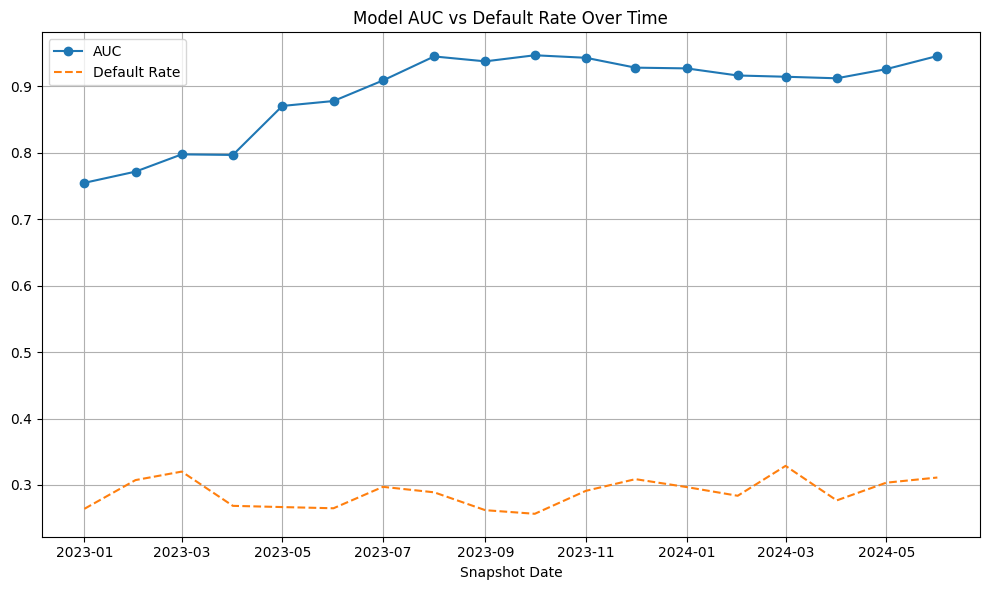

In [20]:
# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["AUC"], marker='o', label='AUC')
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["DefaultRate"], linestyle='--', label='Default Rate')
plt.title("Model AUC vs Default Rate Over Time")
plt.xlabel("Snapshot Date")
plt.legend(); plt.grid(); plt.tight_layout()

reports_dir = "reports/"
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, f"model_perf_trend_{snapshot_date_str.replace('-', '_')}.png"))
print(f"Saved visualization to {reports_dir}")

In [24]:
preds_df = spark.read.parquet("datamart/gold/model_predictions/credit_model_2024_09_01/*.parquet").toPandas()

In [25]:
label_df = spark.read.parquet("datamart/gold/label_store/*.parquet").toPandas()
merged_df = preds_df.merge(label_df, on=["customer_id"], how="left")

In [26]:
merged_df

,customer_id,feature_snapshot_date,model_name,model_predictions,loan_id,label,label_def,snapshot_date
0,CUS_0xa008,None,credit_model_2024_09_01.pkl,0.264498,CUS_0xa008_2023_07_01,0,30dpd_6mob,2024-01-01
1,CUS_0xa049,None,credit_model_2024_09_01.pkl,0.341350,CUS_0xa049_2023_07_01,0,30dpd_6mob,2024-01-01
2,CUS_0xa05a,None,credit_model_2024_09_01.pkl,0.522667,CUS_0xa05a_2023_07_01,1,30dpd_6mob,2024-01-01
3,CUS_0xa05f,None,credit_model_2024_09_01.pkl,0.324368,CUS_0xa05f_2023_07_01,1,30dpd_6mob,2024-01-01
4,CUS_0xa08c,None,credit_model_2024_09_01.pkl,0.159183,CUS_0xa08c_2023_07_01,0,30dpd_6mob,2024-01-01
...,...,...,...,...,...,...,...,...
62813,CUS_0xadc8,2023-09-01,credit_model_2024_09_01.pkl,0.185664,CUS_0xadc8_2023_09_01,0,30dpd_6mob,2024-03-01
62814,CUS_0xaeec,2023-09-01,credit_model_2024_09_01.pkl,0.706006,CUS_0xaeec_2023_09_01,1,30dpd_6mob,2024-03-01
62815,CUS_0xb213,2023-09-01,credit_model_2024_09_01.pkl,0.129936,CUS_0xb213_2023_09_01,1,30dpd_6mob,2024-03-01
62816,CUS_0xb529,2023-09-01,credit_model_2024_09_01.pkl,0.750631,CUS_0xb529_2023_09_01,1,30dpd_6mob,2024-03-01


In [27]:
monthly_perf = (
    merged_df.groupby("feature_snapshot_date", group_keys=False)
    .apply(lambda x: pd.Series({
        "AUC": roc_auc_score(x["label"], x["model_predictions"]) if x["label"].notna().any() else np.nan,
        "DefaultRate": x["label"].mean(),
        "PredMean": x["model_predictions"].mean(),
        "PredStd": x["model_predictions"].std(),
        "Count": len(x)
    }))
    .reset_index()
)

monthly_perf

/tmp/ipykernel_18/1490492943.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,feature_snapshot_date,AUC,DefaultRate,PredMean,PredStd,Count
0,2023-01-01,0.754560,0.264151,0.291846,0.231497,530.0
1,2023-02-01,0.771436,0.307385,0.310344,0.253082,501.0
2,2023-03-01,0.797391,0.320158,0.300873,0.246163,506.0
3,2023-04-01,0.796521,0.268627,0.290243,0.246338,510.0
4,2023-05-01,0.870259,0.266795,0.290587,0.262144,521.0
5,2023-06-01,0.877641,0.264990,0.267064,0.239052,517.0
6,2023-07-01,0.908632,0.297240,0.298793,0.268585,471.0
7,2023-08-01,0.944718,0.288981,0.287272,0.269107,481.0
8,2023-09-01,0.937339,0.262115,0.272428,0.268043,454.0
9,2023-10-01,0.946497,0.256674,0.269383,0.260321,487.0


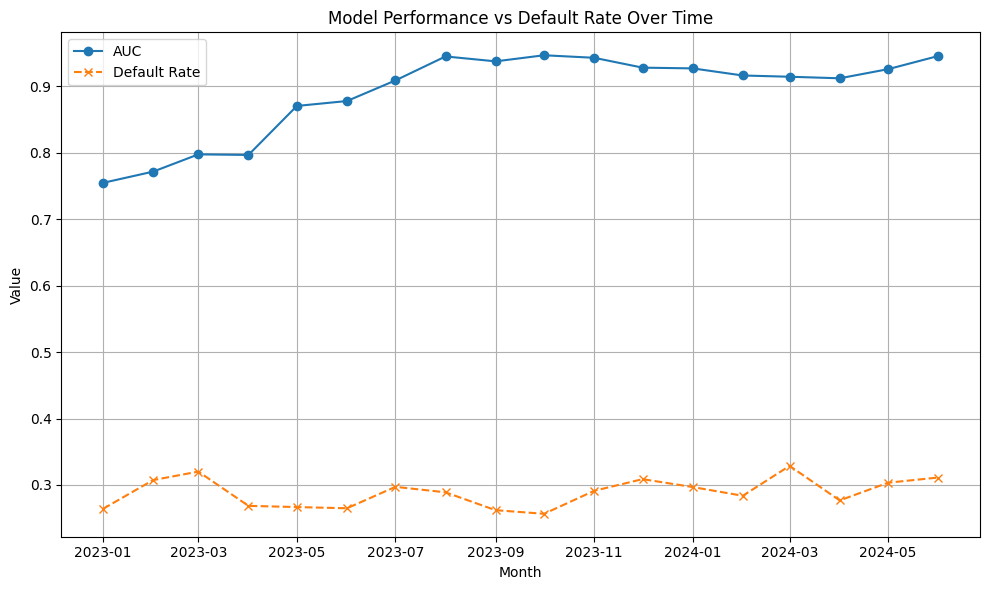

In [28]:
plt.figure(figsize=(10,6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["AUC"], label="AUC", marker='o')
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["DefaultRate"], label="Default Rate", linestyle="--", marker='x')
plt.title("Model Performance vs Default Rate Over Time")
plt.xlabel("Month"); plt.ylabel("Value")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()


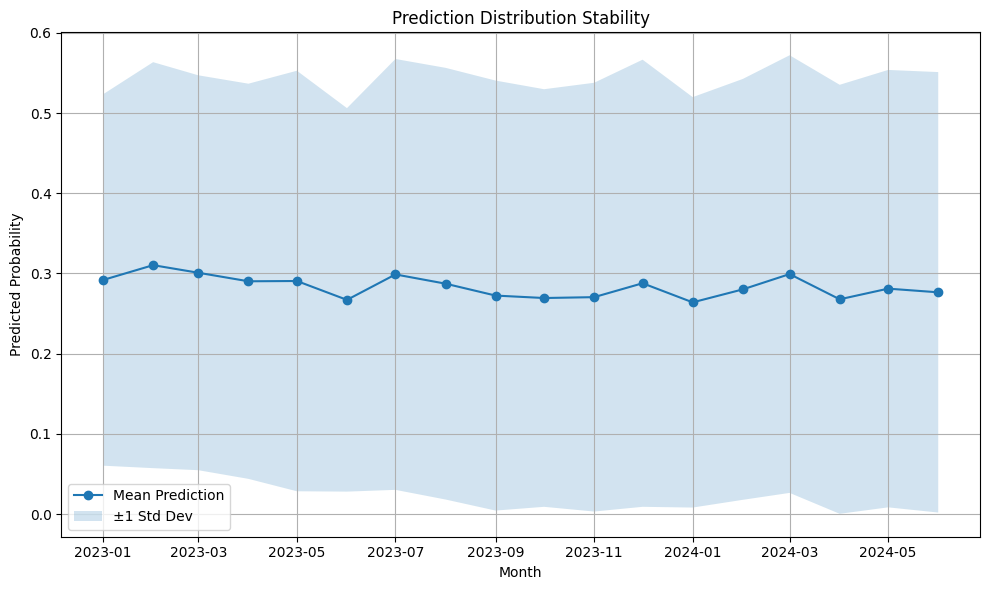

In [31]:
plt.figure(figsize=(10,6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["PredMean"], label="Mean Prediction", marker='o')
plt.fill_between(monthly_perf["feature_snapshot_date"],
                 monthly_perf["PredMean"] - monthly_perf["PredStd"],
                 monthly_perf["PredMean"] + monthly_perf["PredStd"], alpha=0.2, label="±1 Std Dev")
plt.title("Prediction Distribution Stability")
plt.xlabel("Month"); plt.ylabel("Predicted Probability")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()

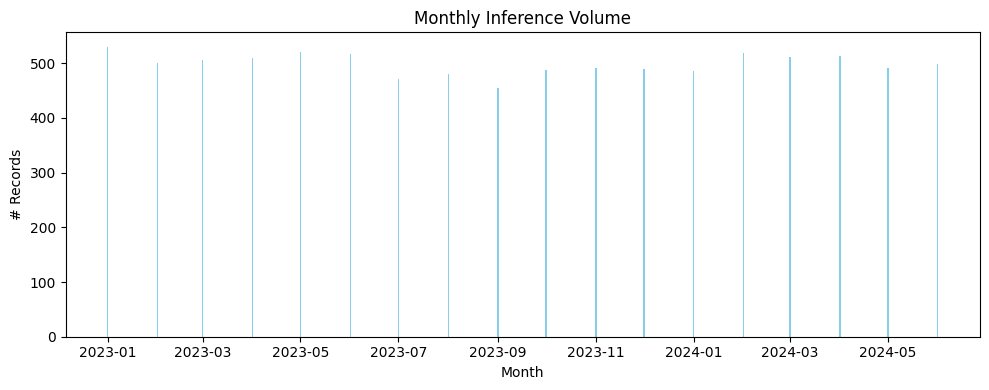

In [32]:
plt.figure(figsize=(10,4))
plt.bar(monthly_perf["feature_snapshot_date"], monthly_perf["Count"], color='skyblue')
plt.title("Monthly Inference Volume")
plt.xlabel("Month"); plt.ylabel("# Records")
plt.tight_layout(); plt.show()


In [33]:
def detect_drift(df, auc_threshold=0.05, pred_mean_shift=0.03):
    ref_auc = df["AUC"].iloc[0]
    ref_pred_mean = df["PredMean"].iloc[0]
    df["AUC_Drift"] = abs(df["AUC"] - ref_auc) > auc_threshold
    df["PredMean_Drift"] = abs(df["PredMean"] - ref_pred_mean) > pred_mean_shift
    df["DriftDetected"] = df["AUC_Drift"] | df["PredMean_Drift"]
    return df

monthly_perf = detect_drift(monthly_perf)
print(monthly_perf[monthly_perf["DriftDetected"]])


   feature_snapshot_date       AUC  DefaultRate  PredMean   PredStd  Count  \
4             2023-05-01  0.870259     0.266795  0.290587  0.262144  521.0   
5             2023-06-01  0.877641     0.264990  0.267064  0.239052  517.0   
6             2023-07-01  0.908632     0.297240  0.298793  0.268585  471.0   
7             2023-08-01  0.944718     0.288981  0.287272  0.269107  481.0   
8             2023-09-01  0.937339     0.262115  0.272428  0.268043  454.0   
9             2023-10-01  0.946497     0.256674  0.269383  0.260321  487.0   
10            2023-11-01  0.942689     0.291242  0.270459  0.267287  491.0   
11            2023-12-01  0.927858     0.308793  0.287793  0.278730  489.0   
12            2024-01-01  0.926747     0.296907  0.263977  0.255850  485.0   
13            2024-02-01  0.916057     0.283784  0.280130  0.262346  518.0   
14            2024-03-01  0.914185     0.328767  0.299227  0.272812  511.0   
15            2024-04-01  0.911848     0.276803  0.267789  0.267